In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

In [2]:

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [3]:
matches = pd.read_csv('matches.csv')
deliveries = pd.read_csv('deliveries.csv')
players = pd.read_csv('players.csv')
seasons = pd.read_csv('seasons.csv')

In [4]:
print(f"Matches:    {matches.shape[0]:,} rows × {matches.shape[1]} columns")
print(f"Deliveries: {deliveries.shape[0]:,} rows × {deliveries.shape[1]} columns")
print(f"Players:    {players.shape[0]:,} rows × {players.shape[1]} columns")
print(f"Seasons:    {seasons.shape[0]:,} rows × {seasons.shape[1]} columns")

Matches:    1,158 rows × 25 columns
Deliveries: 134,190 rows × 18 columns
Players:    580 rows × 12 columns
Seasons:    18 rows × 14 columns


In [5]:
matches.head()

,match_id,season,match_number,stage,date,venue,city,team1,team2,toss_winner,...,second_innings_wickets,second_innings_overs,result,winner,win_by,win_margin,player_of_match,umpire1,umpire2,is_day_night
0,M0001,2008,1,League,2008-03-13,Punjab Cricket Association Stadium,Mohali,Kings XI Punjab,Royal Challengers Bangalore,Royal Challengers Bangalore,...,8,15.4,normal,Kings XI Punjab,runs,81,Moeen Taylor,Aleem Dar,Marais Erasmus,False
1,M0002,2008,2,League,2008-03-14,Greenfield Intl Stadium,Thiruvananthapuram,Mumbai Indians,Kolkata Knight Riders,Mumbai Indians,...,3,18.6,normal,Kolkata Knight Riders,wickets,7,Shai Amla,Michael Gough,Simon Taufel,True
2,M0003,2008,3,League,2008-03-15,M. A. Chidambaram Stadium,Chennai,Chennai Super Kings,Mumbai Indians,Chennai Super Kings,...,2,19.0,normal,Chennai Super Kings,runs,81,Lungi Warner,KN Ananthapadmanabhan,Michael Gough,True
3,M0004,2008,4,League,2008-03-16,DY Patil Stadium,Navi Mumbai,Chennai Super Kings,Deccan Chargers,Chennai Super Kings,...,1,17.4,normal,Deccan Chargers,runs,7,Denesh Cummins,Kumar Dharmasena,Simon Taufel,False
4,M0005,2008,5,League,2008-03-17,Sawai Mansingh Stadium,Jaipur,Rajasthan Royals,Kolkata Knight Riders,Kolkata Knight Riders,...,4,15.4,normal,Kolkata Knight Riders,runs,31,Ollie Siraj,Sundaram Ravi,KN Ananthapadmanabhan,False


In [6]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1158 entries, 0 to 1157
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   match_id                1158 non-null   object 
 1   season                  1158 non-null   int64  
 2   match_number            1158 non-null   int64  
 3   stage                   1158 non-null   object 
 4   date                    1158 non-null   object 
 5   venue                   1158 non-null   object 
 6   city                    1158 non-null   object 
 7   team1                   1158 non-null   object 
 8   team2                   1158 non-null   object 
 9   toss_winner             1158 non-null   object 
 10  toss_decision           1158 non-null   object 
 11  first_innings_score     1158 non-null   int64  
 12  first_innings_wickets   1158 non-null   int64  
 13  first_innings_overs     1158 non-null   float64
 14  second_innings_score    1158 non-null   

In [7]:
print("Missing values per table:")
for name, df in [('matches', matches), ('deliveries', deliveries), ('players', players), ('seasons', seasons)]:
    nulls = df.isnull().sum().sum()
    print(f"  {name}: {nulls} nulls")

Missing values per table:
  matches: 52 nulls
  deliveries: 507011 nulls
  players: 287 nulls
  seasons: 0 nulls


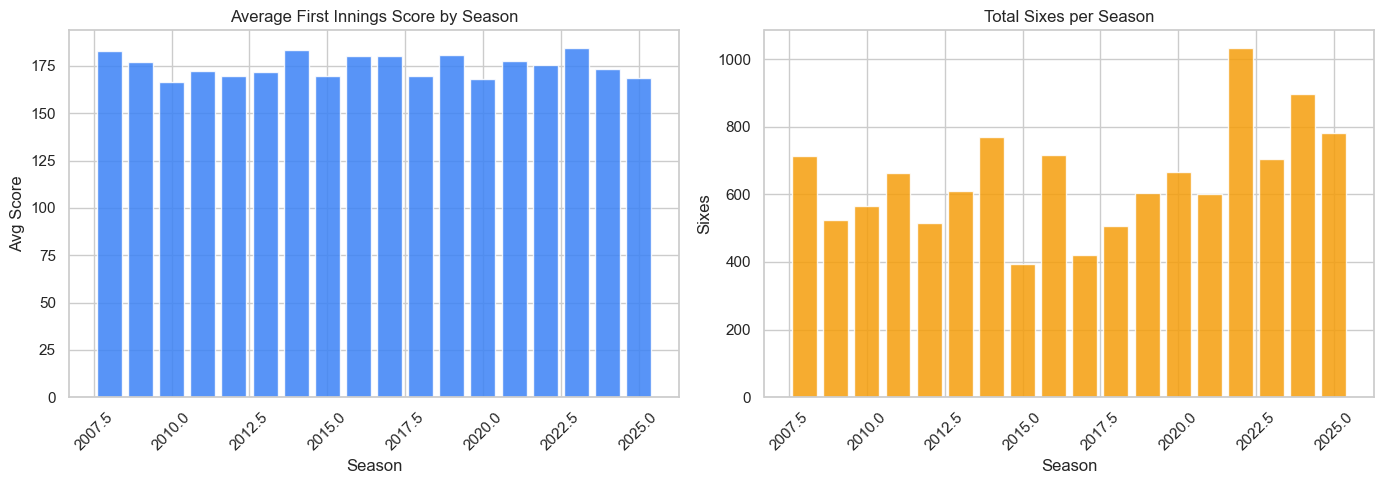

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average first innings score by season
axes[0].bar(seasons['season'], seasons['avg_first_innings_score'], color='#3b82f6', alpha=0.85)
axes[0].set_title('Average First Innings Score by Season')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Avg Score')
axes[0].tick_params(axis='x', rotation=45)
# Sixes per season
axes[1].bar(seasons['season'], seasons['total_sixes'], color='#f59e0b', alpha=0.85)
axes[1].set_title('Total Sixes per Season')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Sixes')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Toss winner also won the match: 46.9% of the time


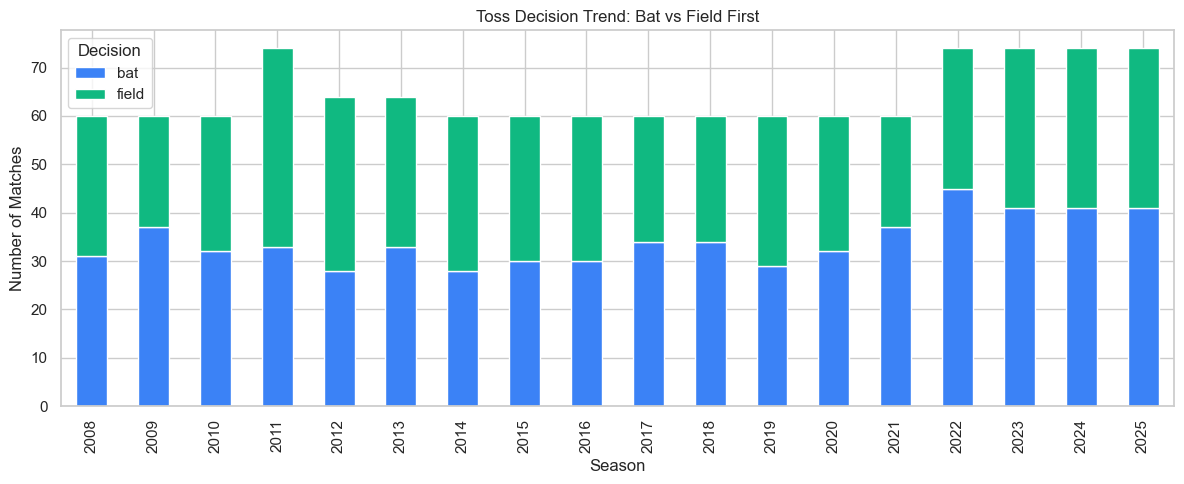

In [10]:
# Filter matches with a clear winner
valid = matches[matches['winner'] != ''].copy()
valid['toss_winner_won'] = valid['toss_winner'] == valid['winner']

toss_win_rate = valid['toss_winner_won'].mean() * 100
print(f"Toss winner also won the match: {toss_win_rate:.1f}% of the time")

# Toss decision trend over seasons
toss_trend = valid.groupby(['season', 'toss_decision']).size().unstack(fill_value=0)
toss_trend.plot(kind='bar', stacked=True, color=['#3b82f6', '#10b981'], figsize=(12, 5))
plt.title('Toss Decision Trend: Bat vs Field First')
plt.xlabel('Season')
plt.ylabel('Number of Matches')
plt.legend(title='Decision')
plt.tight_layout()
plt.show()

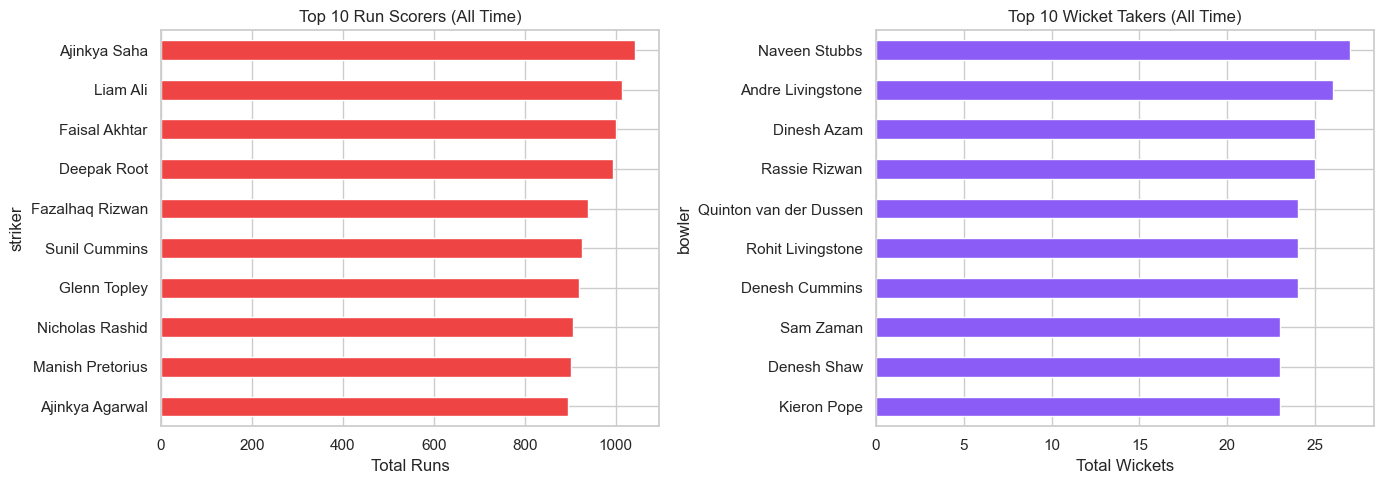

In [11]:
# Top 10 run scorers (all time)
top_batsmen = deliveries.groupby('striker')['batsman_runs'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_batsmen.plot(kind='barh', ax=axes[0], color='#ef4444')
axes[0].set_title('Top 10 Run Scorers (All Time)')
axes[0].set_xlabel('Total Runs')
axes[0].invert_yaxis()

# Top 10 wicket takers
top_bowlers = deliveries[deliveries['is_wicket'] == True].groupby('bowler').size().sort_values(ascending=False).head(10)
top_bowlers.plot(kind='barh', ax=axes[1], color='#8b5cf6')
axes[1].set_title('Top 10 Wicket Takers (All Time)')
axes[1].set_xlabel('Total Wickets')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

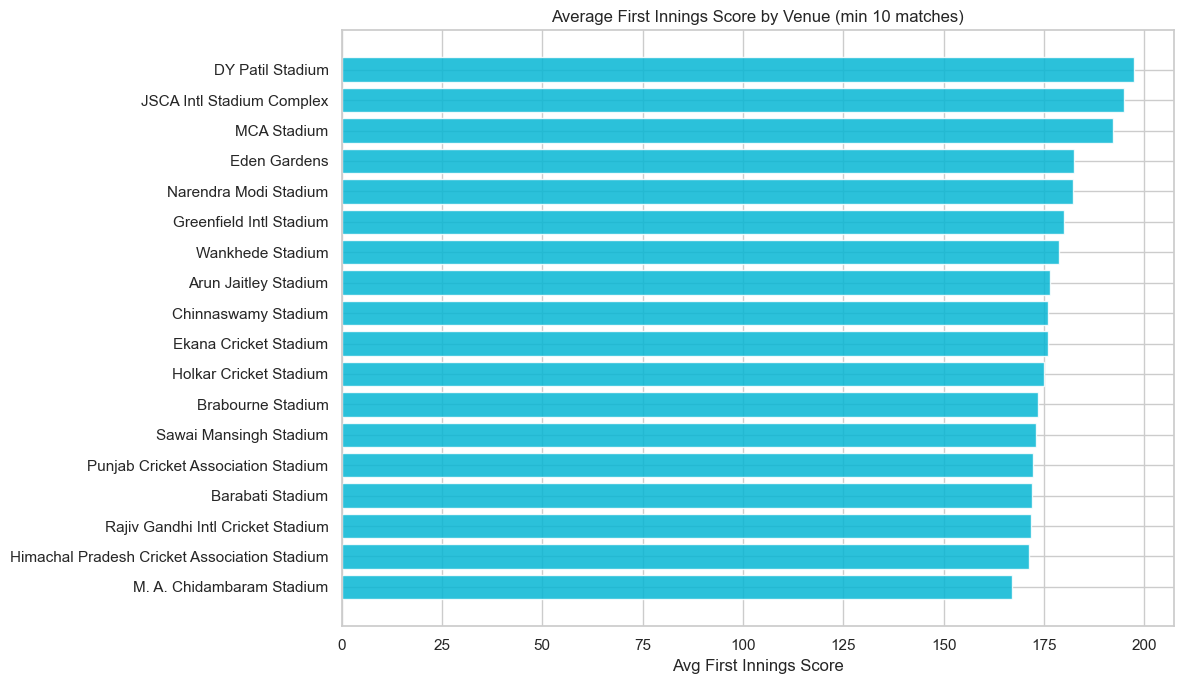

In [12]:
# Average first innings score by venue
venue_avg = matches[matches['result'] == 'normal'].groupby('venue')['first_innings_score'].agg(['mean', 'count'])
venue_avg = venue_avg[venue_avg['count'] >= 10].sort_values('mean', ascending=True)

plt.figure(figsize=(12, 7))
plt.barh(venue_avg.index, venue_avg['mean'], color='#06b6d4', alpha=0.85)
plt.xlabel('Avg First Innings Score')
plt.title('Average First Innings Score by Venue (min 10 matches)')
plt.tight_layout()
plt.show()


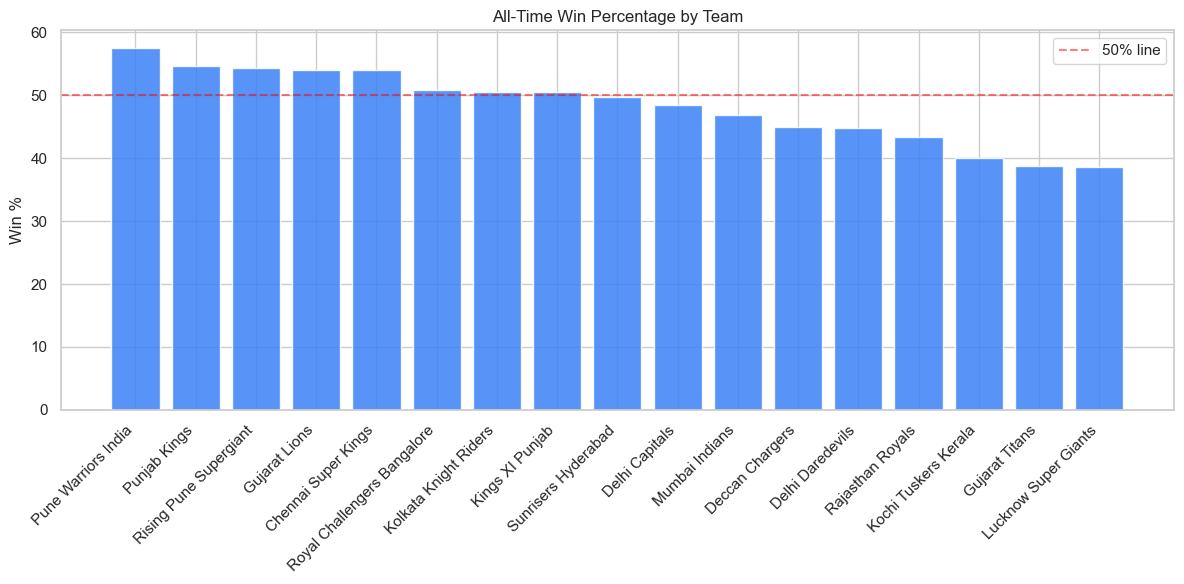

In [13]:
# Win % by team (all time)
wins = valid.groupby('winner').size()
total = pd.concat([valid['team1'], valid['team2']]).value_counts()
win_pct = (wins / total * 100).dropna().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(range(len(win_pct)), win_pct.values, color='#3b82f6', alpha=0.85)
plt.xticks(range(len(win_pct)), win_pct.index, rotation=45, ha='right')
plt.ylabel('Win %')
plt.title('All-Time Win Percentage by Team')
plt.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50% line')
plt.legend()
plt.tight_layout()
plt.show()


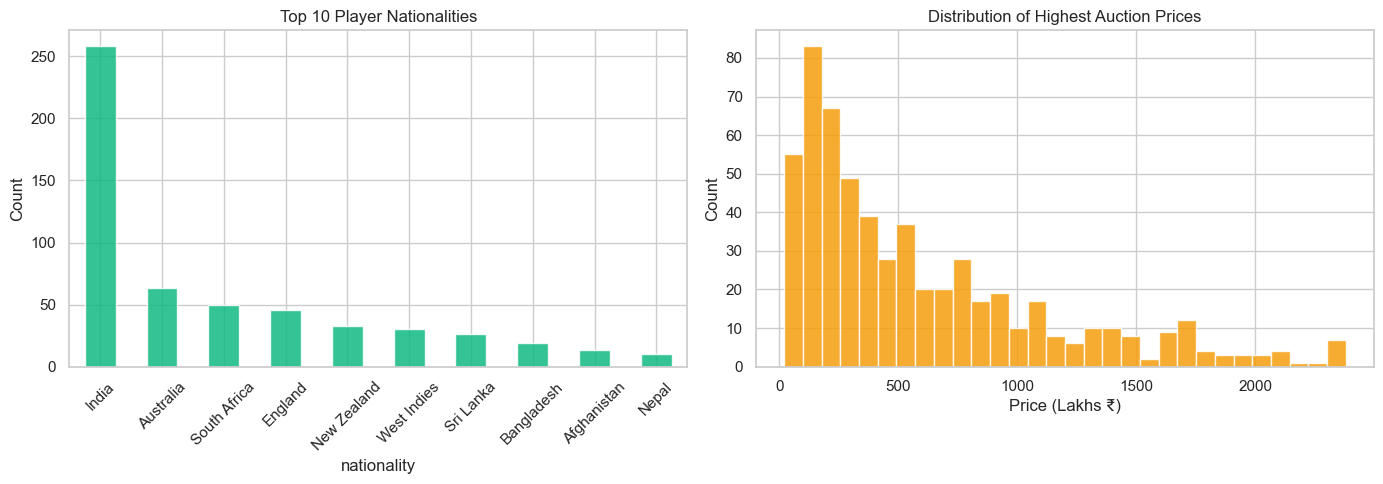

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nationality distribution
nat_counts = players['nationality'].value_counts().head(10)
nat_counts.plot(kind='bar', ax=axes[0], color='#10b981', alpha=0.85)
axes[0].set_title('Top 10 Player Nationalities')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# Auction price distribution
axes[1].hist(players['highest_auction_price_lakh'], bins=30, color='#f59e0b', alpha=0.85, edgecolor='white')
axes[1].set_title('Distribution of Highest Auction Prices')
axes[1].set_xlabel('Price (Lakhs ₹)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [15]:
# Prepare features
ml_data = matches[matches['result'] == 'normal'].copy()
ml_data['winner_is_team1'] = (ml_data['winner'] == ml_data['team1']).astype(int)
ml_data['toss_winner_is_team1'] = (ml_data['toss_winner'] == ml_data['team1']).astype(int)
ml_data['elected_to_bat'] = (ml_data['toss_decision'] == 'bat').astype(int)

# Encode categorical features
le_team1 = LabelEncoder()
le_team2 = LabelEncoder()
le_venue = LabelEncoder()

ml_data['team1_enc'] = le_team1.fit_transform(ml_data['team1'])
ml_data['team2_enc'] = le_team2.fit_transform(ml_data['team2'])
ml_data['venue_enc'] = le_venue.fit_transform(ml_data['venue'])

features = ['team1_enc', 'team2_enc', 'venue_enc', 'toss_winner_is_team1', 
            'elected_to_bat', 'is_day_night', 'season']
X = ml_data[features]
y = ml_data['winner_is_team1']

print(f"Dataset shape: {X.shape}")
print(f"Class balance: {y.value_counts().to_dict()}")

Dataset shape: (1107, 7)
Class balance: {0: 556, 1: 551}


In [16]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print()
print(classification_report(y_test, y_pred, target_names=['Team 2 Wins', 'Team 1 Wins']))

Accuracy: 0.464

              precision    recall  f1-score   support

 Team 2 Wins       0.46      0.39      0.43       112
 Team 1 Wins       0.46      0.54      0.50       110

    accuracy                           0.46       222
   macro avg       0.46      0.46      0.46       222
weighted avg       0.46      0.46      0.46       222



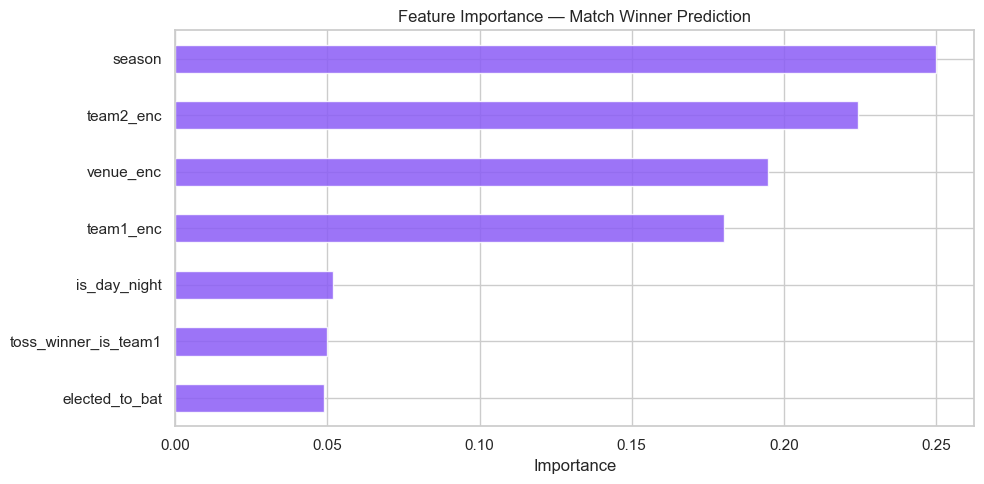

In [17]:
# Feature importance
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='barh', color='#8b5cf6', alpha=0.85)
plt.title('Feature Importance — Match Winner Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

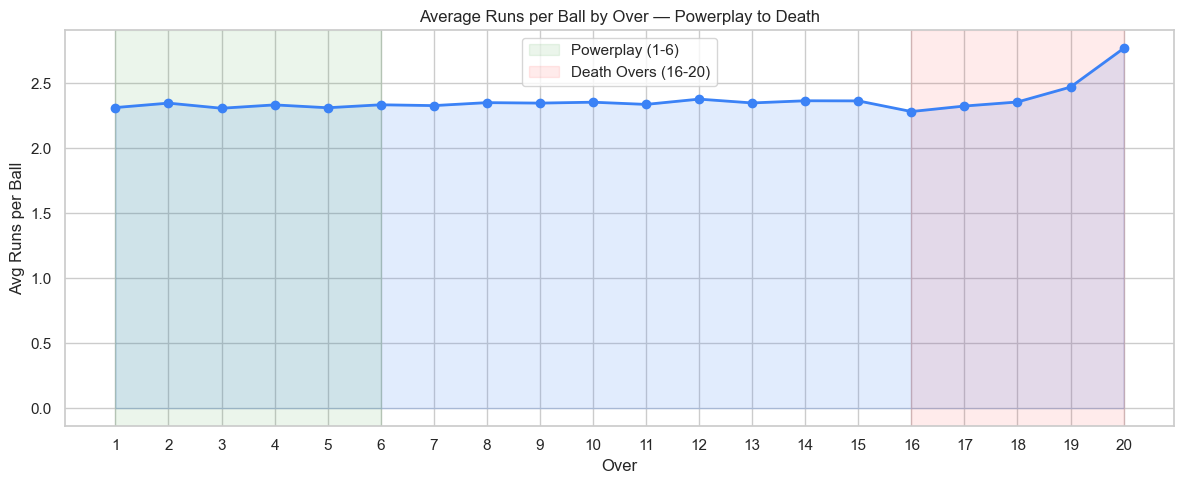

In [ ]:
# Average runs per over across all matches
over_runs = deliveries.groupby('over')['total_runs'].mean()

plt.figure(figsize=(12, 5))
plt.plot(over_runs.index, over_runs.values, marker='o', color='#3b82f6', linewidth=2, markersize=6)
plt.fill_between(over_runs.index, over_runs.values, alpha=0.15, color='#3b82f6')
plt.axvspan(1, 6, alpha=0.08, color='green', label='Powerplay (1-6)')
plt.axvspan(16, 20, alpha=0.08, color='red', label='Death Overs (16-20)')
plt.xlabel('Over')
plt.ylabel('Avg Runs per Ball')
plt.title('Average Runs per Ball by Over — Powerplay to Death')
plt.legend()
plt.xticks(range(1, 21))
plt.tight_layout()
plt.show()